Using device: cuda
Train (NPDD): 24,000  Test (NPDD): 6,000  Test (FER): 4,254
Classes: ['happy', 'neutral', 'sad']
Applied Balanced Manual Weights: [1.  2.  3.6]
Trainable params: 2,227,715 (Entire Network is Trainable)
Epoch   1: Trn_Acc=61.0% | NPDD_Test_Acc=83.0% | FER_Acc=33.0% || Trn_L=1.157 | NPDD_Test_L=0.568 || FER_H=11.7% N=75.7% S=21.2%
         Saved best model! FER=33.03%  H=11.7% N=75.7% S=21.2%
Epoch   2: Trn_Acc=80.7% | NPDD_Test_Acc=91.0% | FER_Acc=34.9% || Trn_L=0.758 | NPDD_Test_L=0.481 || FER_H=10.2% N=75.5% S=29.8%
         Saved best model! FER=34.88%  H=10.2% N=75.5% S=29.8%
Epoch   3: Trn_Acc=85.7% | NPDD_Test_Acc=93.8% | FER_Acc=34.5% || Trn_L=0.662 | NPDD_Test_L=0.438 || FER_H=10.7% N=64.0% S=39.2%
Epoch   4: Trn_Acc=88.8% | NPDD_Test_Acc=96.0% | FER_Acc=34.8% || Trn_L=0.603 | NPDD_Test_L=0.420 || FER_H=11.5% N=85.2% S=18.2%
Epoch   5: Trn_Acc=90.7% | NPDD_Test_Acc=96.0% | FER_Acc=34.5% || Trn_L=0.570 | NPDD_Test_L=0.431 || FER_H=7.2% N=83.0% S=25.3%
Epoch   6

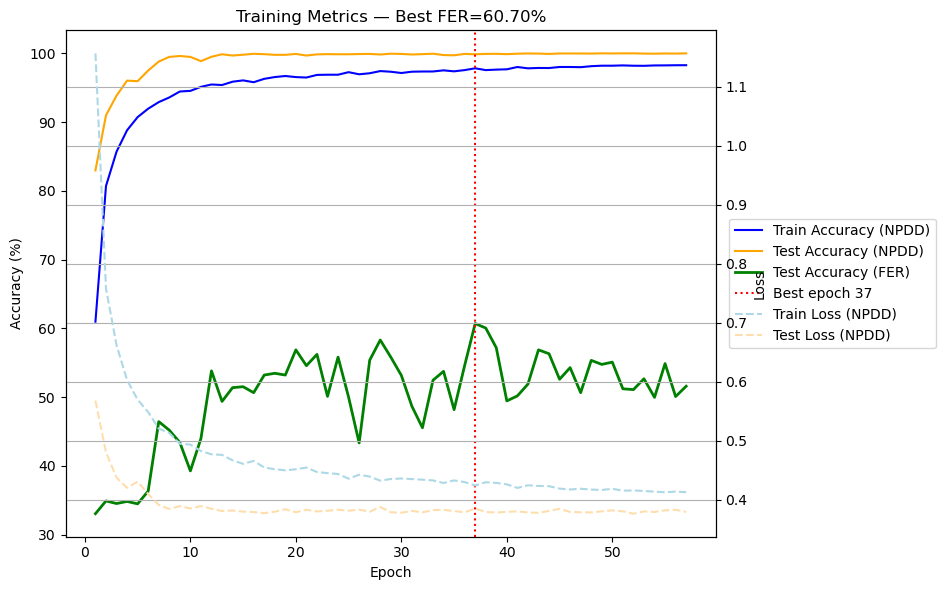

In [24]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
NPDD_DIR  = "/home/student/Downloads/copycat_fer_project/npdd_sl" # Training on NPDD
FER_TEST  = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test" # Testing on FER
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_mobilenetv2_3class.pth"

# CONFIG 
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 3e-4  # Slightly higher initial LR to escape local minima earlier
NUM_CLASSES = 3
IMG_SIZE    = 48
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORMS (Beefed up to combat the 100% NPDD memorization and close the domain gap)
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15), # Increased rotation slightly
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # More translation
    transforms.RandomPerspective(distortion_scale=0.2, p=0.2), # NEW: Helps with different camera angles in FER
    transforms.ColorJitter(brightness=0.4, contrast=0.4), # Bumped slightly for severe lighting gaps
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.1)), # Bumped to force learning from multiple facial zones
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# DATASETS & SPLITTING 
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.subset)

# Load NPDD
full_npdd_ds = datasets.ImageFolder(NPDD_DIR)

test_size  = int(0.2 * len(full_npdd_ds))
train_size = len(full_npdd_ds) - test_size
train_subset, npdd_test_subset = random_split(
    full_npdd_ds, 
    [train_size, test_size], 
    generator=torch.Generator().manual_seed(42)
)

train_ds     = TransformedSubset(train_subset, transform=train_tf)
npdd_test_ds = TransformedSubset(npdd_test_subset, transform=test_tf)
fer_test_ds = datasets.ImageFolder(FER_TEST, transform=test_tf)

train_loader     = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
npdd_test_loader = DataLoader(npdd_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
fer_test_loader  = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train (NPDD): {len(train_ds):,}  Test (NPDD): {len(npdd_test_ds):,}  Test (FER): {len(fer_test_ds):,}")
print(f"Classes: {full_npdd_ds.classes}")

# FOCAL LOSS IMPLEMENTATION
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.20): # Gamma lowered to 2.0, smoothing up to 0.2
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing, reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# BALANCED AGGRESSIVE WEIGHTS: Happy=1.0, Neutral=2.0, Sad=3.6
class_weights = torch.tensor([1.0, 2.0, 3.6], dtype=torch.float).to(DEVICE)
print(f"Applied Balanced Manual Weights: {class_weights.cpu().numpy()}")

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Dropout(0.7), # Keeping this high to combat memorization
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,} (Entire Network is Trainable)")

# LOSS / OPTIMIZER / SCHEDULER 
criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.20) 
# Weight decay optimized to 3e-2 for stricter L2 regularization against NPDD overfitting
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=3e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# TRACKING METRICS 
best_fer_acc        = 0.0
best_epoch          = 0
patience_es         = 20 
counter             = 0

train_acc_list, npdd_test_acc_list, fer_acc_list = [], [], []
train_loss_list, npdd_test_loss_list = [], []

#  TRAINING LOOP
for epoch in range(EPOCHS):

    # TRAIN (NPDD)
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct      += (out.argmax(1) == y).sum().item()
        total        += y.size(0)

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # TEST (On NPDD Split)
    model.eval()
    npdd_test_correct, npdd_test_total, npdd_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            npdd_test_loss += criterion(out, y).item()
            npdd_test_correct += (out.argmax(1) == y).sum().item()
            npdd_test_total += y.size(0)
            
    npdd_test_loss /= len(npdd_test_loader)
    npdd_test_acc = 100 * npdd_test_correct / npdd_test_total
    npdd_test_acc_list.append(npdd_test_acc)
    npdd_test_loss_list.append(npdd_test_loss)

    # TEST (On FER)
    fer_correct, fer_total = 0, 0
    cc = [0] * NUM_CLASSES
    ct = [0] * NUM_CLASSES
    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            pred  = out.argmax(1)
            fer_correct += (pred == y).sum().item()
            fer_total   += y.size(0)
            for i in range(NUM_CLASSES):
                mask   = (y == i)
                cc[i] += (pred[mask] == y[mask]).sum().item()
                ct[i] += mask.sum().item()

    fer_acc = 100 * fer_correct / fer_total
    per_cls = [100 * cc[i] / max(ct[i], 1) for i in range(NUM_CLASSES)]
    fer_acc_list.append(fer_acc)

    print(f"Epoch {epoch+1:>3}: "
          f"Trn_Acc={train_acc:.1f}% | NPDD_Test_Acc={npdd_test_acc:.1f}% | FER_Acc={fer_acc:.1f}% || "
          f"Trn_L={train_loss:.3f} | NPDD_Test_L={npdd_test_loss:.3f} || "
          f"FER_H={per_cls[0]:.1f}% N={per_cls[1]:.1f}% S={per_cls[2]:.1f}%")

    scheduler.step()

    # EARLY STOPPING
    if fer_acc > best_fer_acc:
        best_fer_acc = fer_acc
        best_epoch   = epoch + 1
        counter      = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"         Saved best model! FER={fer_acc:.2f}%  "
              f"H={per_cls[0]:.1f}% N={per_cls[1]:.1f}% S={per_cls[2]:.1f}%")
    else:
        counter += 1
        if counter >= patience_es:
            print("Early stopping triggered")
            break

print("\nBest model saved.")

# FINAL EVALUATION 
print("\nLoading best saved model for final evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

fc, ft = 0, 0
fcc = [0] * NUM_CLASSES
fct = [0] * NUM_CLASSES
with torch.no_grad():
    for x, y in fer_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(x)
        pred = out.argmax(1)
        fc  += (pred == y).sum().item()
        ft  += y.size(0)
        for i in range(NUM_CLASSES):
            mask    = (y == i)
            fcc[i] += (pred[mask] == y[mask]).sum().item()
            fct[i] += mask.sum().item()

final_acc = 100 * fc / ft

print("\n" + "="*50)
print(f"BEST EPOCH        : {best_epoch}")
print(f"FINAL FER TEST ACC: {final_acc:.2f}%")
print(f"\nPer-class accuracy (best model):")
for i, cls in enumerate(fer_test_ds.classes):
    print(f"  {cls:10s}: "
          f"{100*fcc[i]/max(fct[i],1):.2f}%"
          f"  ({fcc[i]}/{fct[i]})")
print("="*50)

# GRAPH 
epochs_range = range(1, len(train_acc_list) + 1)
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy (NPDD)", color='blue')
ax1.plot(epochs_range, npdd_test_acc_list, label="Test Accuracy (NPDD)", color='orange')
ax1.plot(epochs_range, fer_acc_list, label="Test Accuracy (FER)", color='green', linewidth=2)
ax1.axvline(x=best_epoch, color="red", linestyle=":", linewidth=1.5, label=f"Best epoch {best_epoch}")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss (NPDD)", color='lightblue')
ax2.plot(epochs_range, npdd_test_loss_list, linestyle='--', label="Test Loss (NPDD)", color='navajowhite')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", bbox_to_anchor=(1.35, 0.5))

plt.title(f"Training Metrics — Best FER={final_acc:.2f}%")
plt.grid(True)
plt.tight_layout()
plt.show()

Using device: cuda
Train (NPDD): 72,000  Test (NPDD): 18,000  Test (FER): 4,254
Classes: ['happy', 'neutral', 'sad']
Applied Adjusted Manual Weights: [1.  1.8 2.2]
Trainable params: 2,227,715 (Entire Network is Trainable)
Epoch   1: Trn_Acc=91.1% | NPDD_Test_Acc=99.9% | FER_Acc=44.9% || Trn_L=0.329 | NPDD_Test_L=0.145 | FER_L=1.649 || FER_H=82.2% N=34.5% S=2.0%
         Saved best model! FER=44.88%  H=82.2% N=34.5% S=2.0%
Epoch   2: Trn_Acc=96.5% | NPDD_Test_Acc=99.9% | FER_Acc=45.0% || Trn_L=0.217 | NPDD_Test_L=0.143 | FER_L=1.517 || FER_H=59.7% N=62.4% S=6.9%
         Saved best model! FER=44.99%  H=59.7% N=62.4% S=6.9%
Epoch   3: Trn_Acc=97.1% | NPDD_Test_Acc=99.9% | FER_Acc=50.6% || Trn_L=0.202 | NPDD_Test_L=0.146 | FER_L=1.424 || FER_H=86.2% N=43.2% S=7.4%
         Saved best model! FER=50.63%  H=86.2% N=43.2% S=7.4%
Epoch   4: Trn_Acc=97.5% | NPDD_Test_Acc=100.0% | FER_Acc=46.9% || Trn_L=0.194 | NPDD_Test_L=0.144 | FER_L=1.887 || FER_H=96.4% N=19.8% S=3.3%
Epoch   5: Trn_Acc=97.8


BEST EPOCH        : 23
FINAL FER TEST ACC: 58.79%

Per-class accuracy (best model):
  happy     : 76.66%  (1360/1774)
  neutral   : 77.53%  (956/1233)
  sad       : 14.84%  (185/1247)


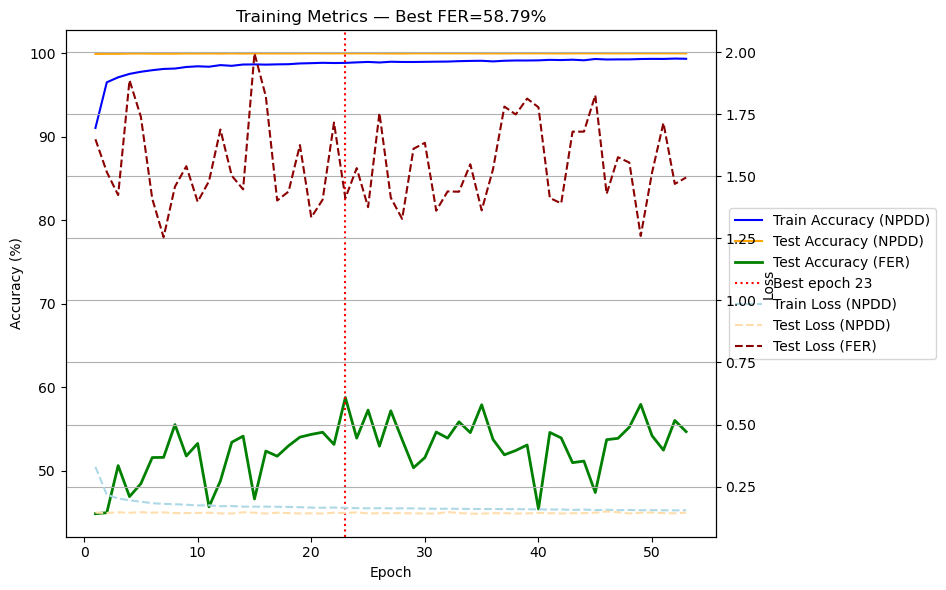

In [15]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
NPDD_DIR  = "/home/student/Downloads/copycat_fer_project/npdd_sl" 
FER_TEST  = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test" 
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat2_mobilenetv2_3class.pth"

# CONFIG 
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 5e-4  
NUM_CLASSES = 3
IMG_SIZE    = 48    
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORMS:
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.10)), 
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# DATASETS & SPLITTING 
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.subset)

# Load NPDD
full_npdd_ds = datasets.ImageFolder(NPDD_DIR)

test_size  = int(0.2 * len(full_npdd_ds))
train_size = len(full_npdd_ds) - test_size
train_subset, npdd_test_subset = random_split(
    full_npdd_ds, 
    [train_size, test_size], 
    generator=torch.Generator().manual_seed(42)
)

train_ds     = TransformedSubset(train_subset, transform=train_tf)
npdd_test_ds = TransformedSubset(npdd_test_subset, transform=test_tf)
fer_test_ds = datasets.ImageFolder(FER_TEST, transform=test_tf)

train_loader     = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
npdd_test_loader = DataLoader(npdd_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
fer_test_loader  = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train (NPDD): {len(train_ds):,}  Test (NPDD): {len(npdd_test_ds):,}  Test (FER): {len(fer_test_ds):,}")
print(f"Classes: {full_npdd_ds.classes}")

# FOCAL LOSS IMPLEMENTATION
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.15): 
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing, reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# REBALANCED WEIGHTS: 
class_weights = torch.tensor([1.0, 1.8, 2.2], dtype=torch.float).to(DEVICE)
print(f"Applied Adjusted Manual Weights: {class_weights.cpu().numpy()}")

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Dropout(0.6), 
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,} (Entire Network is Trainable)")

# LOSS / OPTIMIZER / SCHEDULER 
criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.15) 
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2) 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# TRACKING METRICS 
best_fer_acc        = 0.0
best_epoch          = 0
patience_es         = 30 
counter             = 0

train_acc_list, npdd_test_acc_list, fer_acc_list = [], [], []
train_loss_list, npdd_test_loss_list, fer_loss_list = [], [], [] 

#  TRAINING LOOP
for epoch in range(EPOCHS):

    # TRAIN (NPDD)
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct      += (out.argmax(1) == y).sum().item()
        total        += y.size(0)

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # TEST (On NPDD Split)
    model.eval()
    npdd_test_correct, npdd_test_total, npdd_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            npdd_test_loss += criterion(out, y).item()
            npdd_test_correct += (out.argmax(1) == y).sum().item()
            npdd_test_total += y.size(0)
            
    npdd_test_loss /= len(npdd_test_loader)
    npdd_test_acc = 100 * npdd_test_correct / npdd_test_total
    npdd_test_acc_list.append(npdd_test_acc)
    npdd_test_loss_list.append(npdd_test_loss)

    # TEST (On FER)
    fer_correct, fer_total, fer_test_loss = 0, 0, 0.0 
    cc = [0] * NUM_CLASSES
    ct = [0] * NUM_CLASSES
    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            
            # Calculate FER Test Loss
            loss = criterion(out, y)
            fer_test_loss += loss.item()
            
            pred  = out.argmax(1)
            fer_correct += (pred == y).sum().item()
            fer_total   += y.size(0)
            for i in range(NUM_CLASSES):
                mask   = (y == i)
                cc[i] += (pred[mask] == y[mask]).sum().item()
                ct[i] += mask.sum().item()

    fer_test_loss /= len(fer_test_loader) # Average loss for FER
    fer_loss_list.append(fer_test_loss) # Append to tracking list
    
    fer_acc = 100 * fer_correct / fer_total
    per_cls = [100 * cc[i] / max(ct[i], 1) for i in range(NUM_CLASSES)]
    fer_acc_list.append(fer_acc)

    print(f"Epoch {epoch+1:>3}: "
          f"Trn_Acc={train_acc:.1f}% | NPDD_Test_Acc={npdd_test_acc:.1f}% | FER_Acc={fer_acc:.1f}% || "
          f"Trn_L={train_loss:.3f} | NPDD_Test_L={npdd_test_loss:.3f} | FER_L={fer_test_loss:.3f} || "
          f"FER_H={per_cls[0]:.1f}% N={per_cls[1]:.1f}% S={per_cls[2]:.1f}%")

    scheduler.step()

    # EARLY STOPPING
    if fer_acc > best_fer_acc:
        best_fer_acc = fer_acc
        best_epoch   = epoch + 1
        counter      = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"         Saved best model! FER={fer_acc:.2f}%  "
              f"H={per_cls[0]:.1f}% N={per_cls[1]:.1f}% S={per_cls[2]:.1f}%")
    else:
        counter += 1
        if counter >= patience_es:
            print("Early stopping triggered")
            break

print("\nBest model saved.")

# FINAL EVALUATION 
print("\nLoading best saved model for final evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

fc, ft = 0, 0
fcc = [0] * NUM_CLASSES
fct = [0] * NUM_CLASSES
with torch.no_grad():
    for x, y in fer_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(x)
        pred = out.argmax(1)
        fc  += (pred == y).sum().item()
        ft  += y.size(0)
        for i in range(NUM_CLASSES):
            mask    = (y == i)
            fcc[i] += (pred[mask] == y[mask]).sum().item()
            fct[i] += mask.sum().item()

final_acc = 100 * fc / ft

print("\n" + "="*50)
print(f"BEST EPOCH        : {best_epoch}")
print(f"FINAL FER TEST ACC: {final_acc:.2f}%")
print(f"\nPer-class accuracy (best model):")
for i, cls in enumerate(fer_test_ds.classes):
    print(f"  {cls:10s}: "
          f"{100*fcc[i]/max(fct[i],1):.2f}%"
          f"  ({fcc[i]}/{fct[i]})")
print("="*50)

# GRAPH 
epochs_range = range(1, len(train_acc_list) + 1)
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy (NPDD)", color='blue')
ax1.plot(epochs_range, npdd_test_acc_list, label="Test Accuracy (NPDD)", color='orange')
ax1.plot(epochs_range, fer_acc_list, label="Test Accuracy (FER)", color='green', linewidth=2)
ax1.axvline(x=best_epoch, color="red", linestyle=":", linewidth=1.5, label=f"Best epoch {best_epoch}")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss (NPDD)", color='lightblue')
ax2.plot(epochs_range, npdd_test_loss_list, linestyle='--', label="Test Loss (NPDD)", color='navajowhite')
ax2.plot(epochs_range, fer_loss_list, linestyle='--', label="Test Loss (FER)", color='darkred') 

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", bbox_to_anchor=(1.35, 0.5))

plt.title(f"Training Metrics — Best FER={final_acc:.2f}%")
plt.grid(True)
plt.tight_layout()
plt.show()

Using device: cuda
NPDD Train: 48,000 | NPDD Test: 12,000
FER Target Test: 3,021
Classes: ['happy', 'sad']
Trainable params: 2,226,434
Epoch   1: NPDD Tr_Acc=98.71% | NPDD Te_Acc=99.67% | FER Te_Acc=58.89% || NPDD Tr_L=0.227 | NPDD Te_L=0.208 | FER_L=1.009 | H=99.8% S=0.7%
         >>> Saved Epoch 1: Best FER Acc=58.89% (H=99.8% S=0.7%)
Epoch   2: NPDD Tr_Acc=99.90% | NPDD Te_Acc=99.89% | FER Te_Acc=64.58% || NPDD Tr_L=0.202 | NPDD Te_L=0.202 | FER_L=0.692 | H=75.8% S=48.6%
         >>> Saved Epoch 2: Best FER Acc=64.58% (H=75.8% S=48.6%)
Epoch   3: NPDD Tr_Acc=99.92% | NPDD Te_Acc=99.97% | FER Te_Acc=67.56% || NPDD Tr_L=0.201 | NPDD Te_L=0.200 | FER_L=0.720 | H=79.3% S=50.9%
         >>> Saved Epoch 3: Best FER Acc=67.56% (H=79.3% S=50.9%)
Epoch   4: NPDD Tr_Acc=99.97% | NPDD Te_Acc=99.96% | FER Te_Acc=58.76% || NPDD Tr_L=0.200 | NPDD Te_L=0.202 | FER_L=1.036 | H=99.8% S=0.3%
Epoch   5: NPDD Tr_Acc=99.91% | NPDD Te_Acc=99.99% | FER Te_Acc=61.27% || NPDD Tr_L=0.201 | NPDD Te_L=0.199 | 

Epoch  55: NPDD Tr_Acc=100.00% | NPDD Te_Acc=100.00% | FER Te_Acc=58.49% || NPDD Tr_L=0.199 | NPDD Te_L=0.202 | FER_L=1.026 | H=35.6% S=91.0%
Epoch  56: NPDD Tr_Acc=100.00% | NPDD Te_Acc=100.00% | FER Te_Acc=56.44% || NPDD Tr_L=0.199 | NPDD Te_L=0.202 | FER_L=1.035 | H=32.2% S=90.9%
Epoch  57: NPDD Tr_Acc=100.00% | NPDD Te_Acc=100.00% | FER Te_Acc=45.91% || NPDD Tr_L=0.199 | NPDD Te_L=0.201 | FER_L=1.376 | H=9.7% S=97.4%
Epoch  58: NPDD Tr_Acc=100.00% | NPDD Te_Acc=100.00% | FER Te_Acc=42.01% || NPDD Tr_L=0.199 | NPDD Te_L=0.201 | FER_L=1.553 | H=1.4% S=99.8%
Epoch  59: NPDD Tr_Acc=100.00% | NPDD Te_Acc=100.00% | FER Te_Acc=41.81% || NPDD Tr_L=0.199 | NPDD Te_L=0.201 | FER_L=1.558 | H=1.0% S=99.8%
Epoch  60: NPDD Tr_Acc=100.00% | NPDD Te_Acc=99.99% | FER Te_Acc=43.69% || NPDD Tr_L=0.199 | NPDD Te_L=0.202 | FER_L=1.448 | H=4.9% S=98.9%
Epoch  61: NPDD Tr_Acc=100.00% | NPDD Te_Acc=100.00% | FER Te_Acc=46.77% || NPDD Tr_L=0.199 | NPDD Te_L=0.202 | FER_L=1.333 | H=10.7% S=98.2%
Early stopp

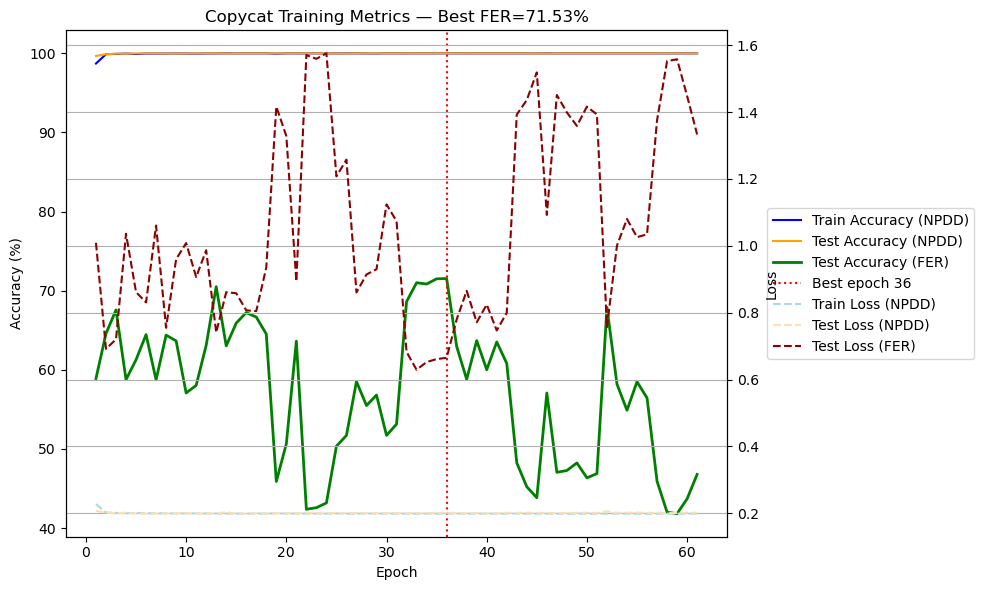

In [37]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ==========================================
# PATHS
# ==========================================
NPDD_DIR     = "/home/student/Downloads/copycat_fer_project/npdd_sl"
FER_TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH    = "/home/student/Downloads/copycat_fer_project/copycat_mobilenetv2_2class.pth"

# ==========================================
# CONFIG
# ==========================================
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 5e-4  # Gentle learning rate for transfer learning
NUM_CLASSES = 2  
IMG_SIZE    = 48
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ==========================================
# TRANSFORMS (Heavy Augmentation to bridge Domain Gap)
# ==========================================
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# DATASETS & DATALOADERS
# ==========================================
# 1. NPDD Dataset (Train / Test Split)
npdd_full = datasets.ImageFolder(NPDD_DIR, transform=train_tf)

if len(npdd_full.classes) != 2:
    raise ValueError(f"NPDD Expected 2 classes, found {len(npdd_full.classes)}: {npdd_full.classes}")

val_size   = int(0.2 * len(npdd_full))
train_size = len(npdd_full) - val_size
npdd_train_ds, npdd_test_ds = random_split(npdd_full, [train_size, val_size])

# Note: We apply test_tf to the validation split dynamically by overriding it (best practice without writing a custom class)
npdd_test_ds.dataset.transform = test_tf

npdd_train_loader = DataLoader(npdd_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
npdd_test_loader  = DataLoader(npdd_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# 2. FER Target Test Dataset
fer_test_ds = datasets.ImageFolder(FER_TEST_DIR, transform=test_tf)

if len(fer_test_ds.classes) != 2:
    raise ValueError(f"FER Expected 2 classes, found {len(fer_test_ds.classes)}: {fer_test_ds.classes}")

fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"NPDD Train: {len(npdd_train_ds):,} | NPDD Test: {len(npdd_test_ds):,}")
print(f"FER Target Test: {len(fer_test_ds):,}")
print(f"Classes: {npdd_full.classes}")

# ==========================================
# MODEL (Same as Target)
# ==========================================
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model = model.to(DEVICE)

for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

# ==========================================
# LOSS / OPTIMIZER / SCHEDULER
# ==========================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3) 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ==========================================
# EARLY STOPPING (Tracking FER Test Accuracy)
# ==========================================
best_fer_acc     = 0.0          
best_epoch       = 0
patience_es      = 25 
counter          = 0

# Lists for graphing
npdd_train_acc_list  = []
npdd_test_acc_list   = []
fer_test_acc_list    = []
npdd_train_loss_list = []
npdd_test_loss_list  = []
fer_test_loss_list   = []

# ==========================================
# TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):

    # -------------------------
    # 1. TRAIN (NPDD)
    # -------------------------
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for x, y in npdd_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct      += (out.argmax(1) == y).sum().item()
        total        += y.size(0)

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(npdd_train_loader)
    
    npdd_train_acc_list.append(train_acc)
    npdd_train_loss_list.append(train_loss)

    # -------------------------
    # 2. VALIDATION (NPDD Test Split)
    # -------------------------
    model.eval()
    npdd_test_correct, npdd_test_total, npdd_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            npdd_test_loss += criterion(out, y).item()
            npdd_test_correct += (out.argmax(1) == y).sum().item()
            npdd_test_total += y.size(0)
            
    npdd_val_acc = 100 * npdd_test_correct / npdd_test_total
    npdd_test_loss /= len(npdd_test_loader)
    
    npdd_test_acc_list.append(npdd_val_acc)
    npdd_test_loss_list.append(npdd_test_loss)

    # -------------------------
    # 3. EVALUATION (FER Target Test)
    # -------------------------
    fer_correct, fer_total, fer_loss = 0, 0, 0.0
    cc = [0] * NUM_CLASSES
    ct = [0] * NUM_CLASSES
    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            pred  = out.argmax(1)
            fer_loss    += criterion(out, y).item()
            fer_correct += (pred == y).sum().item()
            fer_total   += y.size(0)
            for i in range(NUM_CLASSES):
                mask   = (y == i)
                cc[i] += (pred[mask] == y[mask]).sum().item()
                ct[i] += mask.sum().item()

    fer_acc  = 100 * fer_correct / fer_total
    fer_loss /= len(fer_test_loader)
    per_cls  = [100 * cc[i] / max(ct[i], 1) for i in range(NUM_CLASSES)]

    fer_test_acc_list.append(fer_acc)
    fer_test_loss_list.append(fer_loss)

    # Output Printing
    print(f"Epoch {epoch+1:>3}: "
          f"NPDD Tr_Acc={train_acc:.2f}% | NPDD Te_Acc={npdd_val_acc:.2f}% | FER Te_Acc={fer_acc:.2f}% || "
          f"NPDD Tr_L={train_loss:.3f} | NPDD Te_L={npdd_test_loss:.3f} | FER_L={fer_loss:.3f} | "
          f"H={per_cls[0]:.1f}% S={per_cls[1]:.1f}%")

    scheduler.step()

    # -------------------------
    # EARLY STOPPING (Based on Target FER Acc)
    # -------------------------
    if fer_acc > best_fer_acc:
        best_fer_acc = fer_acc          
        best_epoch   = epoch + 1       
        counter      = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"         >>> Saved Epoch {best_epoch}: Best FER Acc={fer_acc:.2f}% (H={per_cls[0]:.1f}% S={per_cls[1]:.1f}%)")
    else:
        counter += 1
        if counter >= patience_es:
            print(f"Early stopping triggered after {patience_es} epochs without FER test improvement.")
            break

print("\nBest copycat model saved.")

# ==========================================
# FINAL EVALUATION
# ==========================================
print("\nLoading best saved model for final evaluation on FER...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

fc, ft = 0, 0
fcc = [0] * NUM_CLASSES
fct = [0] * NUM_CLASSES
with torch.no_grad():
    for x, y in fer_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(x)
        pred = out.argmax(1)
        fc  += (pred == y).sum().item()
        ft  += y.size(0)
        for i in range(NUM_CLASSES):
            mask    = (y == i)
            fcc[i] += (pred[mask] == y[mask]).sum().item()
            fct[i] += mask.sum().item()

final_acc = 100 * fc / ft

print("\n" + "="*50)
print(f"BEST EPOCH        : {best_epoch}")
print(f"FINAL FER TEST ACC: {final_acc:.2f}%")
print(f"\nPer-class accuracy (best model):")
for i, cls in enumerate(fer_test_ds.classes):
    print(f"  {cls:10s}: "
          f"{100*fcc[i]/max(fct[i],1):.2f}%"
          f"  ({fcc[i]}/{fct[i]})")
print("="*50)

# ==========================================
# GRAPH
# ==========================================
epochs_range = range(1, len(npdd_train_acc_list) + 1)
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, npdd_train_acc_list, label="Train Accuracy (NPDD)", color="blue")
ax1.plot(epochs_range, npdd_test_acc_list,  label="Test Accuracy (NPDD)", color="orange")
ax1.plot(epochs_range, fer_test_acc_list,   label="Test Accuracy (FER)", color="green", linewidth=2)
ax1.axvline(x=best_epoch, color="red", linestyle=":", linewidth=1.5, label=f"Best epoch {best_epoch}")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, npdd_train_loss_list, linestyle='--', color="lightblue", label="Train Loss (NPDD)")
ax2.plot(epochs_range, npdd_test_loss_list,  linestyle='--', color="navajowhite", label="Test Loss (NPDD)")
ax2.plot(epochs_range, fer_test_loss_list,   linestyle='--', color="darkred", label="Test Loss (FER)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", bbox_to_anchor=(1.05, 0.5))

plt.title(f"Copycat Training Metrics — Best FER={final_acc:.2f}%")
plt.grid(True)
plt.tight_layout()
plt.show()

Using device: cuda
NPDD Train: 48,000 | NPDD Test: 12,000
FER Target Test: 3,021
Classes: ['happy', 'sad']
Trainable params: 2,226,434
Epoch   1: NPDD Tr_Acc=98.41% | NPDD Te_Acc=99.86% | FER Te_Acc=60.34% || NPDD Tr_L=0.228 | NPDD Te_L=0.200 | FER_L=0.832 | H=95.5% S=10.3%
         >>> Saved Epoch 1: Best FER Acc=60.34% (H=95.5% S=10.3%)
Epoch   2: NPDD Tr_Acc=99.87% | NPDD Te_Acc=99.92% | FER Te_Acc=61.93% || NPDD Tr_L=0.199 | NPDD Te_L=0.198 | FER_L=0.752 | H=92.8% S=18.0%
         >>> Saved Epoch 2: Best FER Acc=61.93% (H=92.8% S=18.0%)
Epoch   3: NPDD Tr_Acc=99.92% | NPDD Te_Acc=99.98% | FER Te_Acc=59.62% || NPDD Tr_L=0.197 | NPDD Te_L=0.196 | FER_L=1.053 | H=99.7% S=2.6%
Epoch   4: NPDD Tr_Acc=99.92% | NPDD Te_Acc=99.90% | FER Te_Acc=59.29% || NPDD Tr_L=0.198 | NPDD Te_L=0.198 | FER_L=1.207 | H=99.8% S=1.7%
Epoch   5: NPDD Tr_Acc=99.96% | NPDD Te_Acc=99.97% | FER Te_Acc=63.72% || NPDD Tr_L=0.197 | NPDD Te_L=0.196 | FER_L=0.873 | H=95.5% S=18.4%
         >>> Saved Epoch 5: Best FE


BEST EPOCH        : 29
FINAL FER TEST ACC: 72.29%

Per-class accuracy (best model):
  happy     : 64.66%  (1147/1774)
  sad       : 83.16%  (1037/1247)


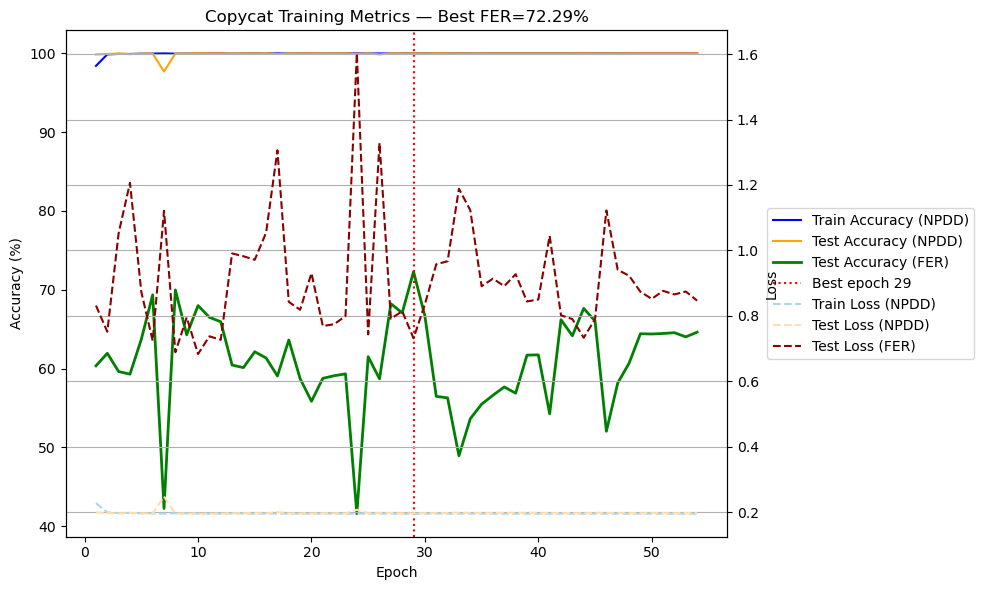

In [52]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ==========================================
# PATHS
# ==========================================
NPDD_DIR     = "/home/student/Downloads/copycat_fer_project/npdd_sl"
FER_TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH    = "/home/student/Downloads/copycat_fer_project/copycat2_mobilenetv2_2class.pth"

# ==========================================
# CONFIG
# ==========================================
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 5e-4  
NUM_CLASSES = 2  
IMG_SIZE    = 48
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ==========================================
# TRANSFORMS 
# ==========================================
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# DATASETS & DATALOADERS
# ==========================================
# 1. NPDD Dataset (Train / Test Split)
npdd_full = datasets.ImageFolder(NPDD_DIR, transform=train_tf)

if len(npdd_full.classes) != 2:
    raise ValueError(f"NPDD Expected 2 classes, found {len(npdd_full.classes)}: {npdd_full.classes}")

val_size   = int(0.2 * len(npdd_full))
train_size = len(npdd_full) - val_size
npdd_train_ds, npdd_test_ds = random_split(npdd_full, [train_size, val_size])

# Note: We apply test_tf to the validation split dynamically by overriding it (best practice without writing a custom class)
npdd_test_ds.dataset.transform = test_tf

npdd_train_loader = DataLoader(npdd_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
npdd_test_loader  = DataLoader(npdd_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# 2. FER Target Test Dataset
fer_test_ds = datasets.ImageFolder(FER_TEST_DIR, transform=test_tf)

if len(fer_test_ds.classes) != 2:
    raise ValueError(f"FER Expected 2 classes, found {len(fer_test_ds.classes)}: {fer_test_ds.classes}")

fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"NPDD Train: {len(npdd_train_ds):,} | NPDD Test: {len(npdd_test_ds):,}")
print(f"FER Target Test: {len(fer_test_ds):,}")
print(f"Classes: {npdd_full.classes}")

# ==========================================
# MODEL (Reverted to your original logic)
# ==========================================
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model = model.to(DEVICE)

# Train all layers, as you originally did
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

# ==========================================
# LOSS / OPTIMIZER / SCHEDULER
# ==========================================
class_weights = torch.tensor([1.5, 1.0]).to(DEVICE)

# Apply weights to your original criterion
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1) 
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3) 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ==========================================
# EARLY STOPPING (Tracking FER Test Accuracy)
# ==========================================
best_fer_acc     = 0.0          
best_epoch       = 0
patience_es      = 25 
counter          = 0

# Lists for graphing
npdd_train_acc_list  = []
npdd_test_acc_list   = []
fer_test_acc_list    = []
npdd_train_loss_list = []
npdd_test_loss_list  = []
fer_test_loss_list   = []

# ==========================================
# TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):

    # -------------------------
    # 1. TRAIN (NPDD)
    # -------------------------
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for x, y in npdd_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct      += (out.argmax(1) == y).sum().item()
        total        += y.size(0)

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(npdd_train_loader)
    
    npdd_train_acc_list.append(train_acc)
    npdd_train_loss_list.append(train_loss)

    # -------------------------
    # 2. VALIDATION (NPDD Test Split)
    # -------------------------
    model.eval()
    npdd_test_correct, npdd_test_total, npdd_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            npdd_test_loss += criterion(out, y).item()
            npdd_test_correct += (out.argmax(1) == y).sum().item()
            npdd_test_total += y.size(0)
            
    npdd_val_acc = 100 * npdd_test_correct / npdd_test_total
    npdd_test_loss /= len(npdd_test_loader)
    
    npdd_test_acc_list.append(npdd_val_acc)
    npdd_test_loss_list.append(npdd_test_loss)

    # -------------------------
    # 3. EVALUATION (FER Target Test)
    # -------------------------
    fer_correct, fer_total, fer_loss = 0, 0, 0.0
    cc = [0] * NUM_CLASSES
    ct = [0] * NUM_CLASSES
    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            pred  = out.argmax(1)
            fer_loss    += criterion(out, y).item()
            fer_correct += (pred == y).sum().item()
            fer_total   += y.size(0)
            for i in range(NUM_CLASSES):
                mask   = (y == i)
                cc[i] += (pred[mask] == y[mask]).sum().item()
                ct[i] += mask.sum().item()

    fer_acc  = 100 * fer_correct / fer_total
    fer_loss /= len(fer_test_loader)
    per_cls  = [100 * cc[i] / max(ct[i], 1) for i in range(NUM_CLASSES)]

    fer_test_acc_list.append(fer_acc)
    fer_test_loss_list.append(fer_loss)

    # Output Printing
    print(f"Epoch {epoch+1:>3}: "
          f"NPDD Tr_Acc={train_acc:.2f}% | NPDD Te_Acc={npdd_val_acc:.2f}% | FER Te_Acc={fer_acc:.2f}% || "
          f"NPDD Tr_L={train_loss:.3f} | NPDD Te_L={npdd_test_loss:.3f} | FER_L={fer_loss:.3f} | "
          f"H={per_cls[0]:.1f}% S={per_cls[1]:.1f}%")

    scheduler.step()

    # -------------------------
    # EARLY STOPPING (Based on Target FER Acc)
    # -------------------------
    if fer_acc > best_fer_acc:
        best_fer_acc = fer_acc          
        best_epoch   = epoch + 1       
        counter      = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"         >>> Saved Epoch {best_epoch}: Best FER Acc={fer_acc:.2f}% (H={per_cls[0]:.1f}% S={per_cls[1]:.1f}%)")
    else:
        counter += 1
        if counter >= patience_es:
            print(f"Early stopping triggered after {patience_es} epochs without FER test improvement.")
            break

print("\nBest copycat model saved.")

# ==========================================
# FINAL EVALUATION
# ==========================================
print("\nLoading best saved model for final evaluation on FER...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

fc, ft = 0, 0
fcc = [0] * NUM_CLASSES
fct = [0] * NUM_CLASSES
with torch.no_grad():
    for x, y in fer_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(x)
        pred = out.argmax(1)
        fc  += (pred == y).sum().item()
        ft  += y.size(0)
        for i in range(NUM_CLASSES):
            mask    = (y == i)
            fcc[i] += (pred[mask] == y[mask]).sum().item()
            fct[i] += mask.sum().item()

final_acc = 100 * fc / ft

print("\n" + "="*50)
print(f"BEST EPOCH        : {best_epoch}")
print(f"FINAL FER TEST ACC: {final_acc:.2f}%")
print(f"\nPer-class accuracy (best model):")
for i, cls in enumerate(fer_test_ds.classes):
    print(f"  {cls:10s}: "
          f"{100*fcc[i]/max(fct[i],1):.2f}%"
          f"  ({fcc[i]}/{fct[i]})")
print("="*50)

# ==========================================
# GRAPH
# ==========================================
epochs_range = range(1, len(npdd_train_acc_list) + 1)
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, npdd_train_acc_list, label="Train Accuracy (NPDD)", color="blue")
ax1.plot(epochs_range, npdd_test_acc_list,  label="Test Accuracy (NPDD)", color="orange")
ax1.plot(epochs_range, fer_test_acc_list,   label="Test Accuracy (FER)", color="green", linewidth=2)
ax1.axvline(x=best_epoch, color="red", linestyle=":", linewidth=1.5, label=f"Best epoch {best_epoch}")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, npdd_train_loss_list, linestyle='--', color="lightblue", label="Train Loss (NPDD)")
ax2.plot(epochs_range, npdd_test_loss_list,  linestyle='--', color="navajowhite", label="Test Loss (NPDD)")
ax2.plot(epochs_range, fer_test_loss_list,   linestyle='--', color="darkred", label="Test Loss (FER)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", bbox_to_anchor=(1.05, 0.5))

plt.title(f"Copycat Training Metrics — Best FER={final_acc:.2f}%")
plt.grid(True)
plt.tight_layout()
plt.show()

Model loaded.
  happy: 10 images
  sad: 10 images


/tmp/ipykernel_5405/396108980.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: confidence_happy.png


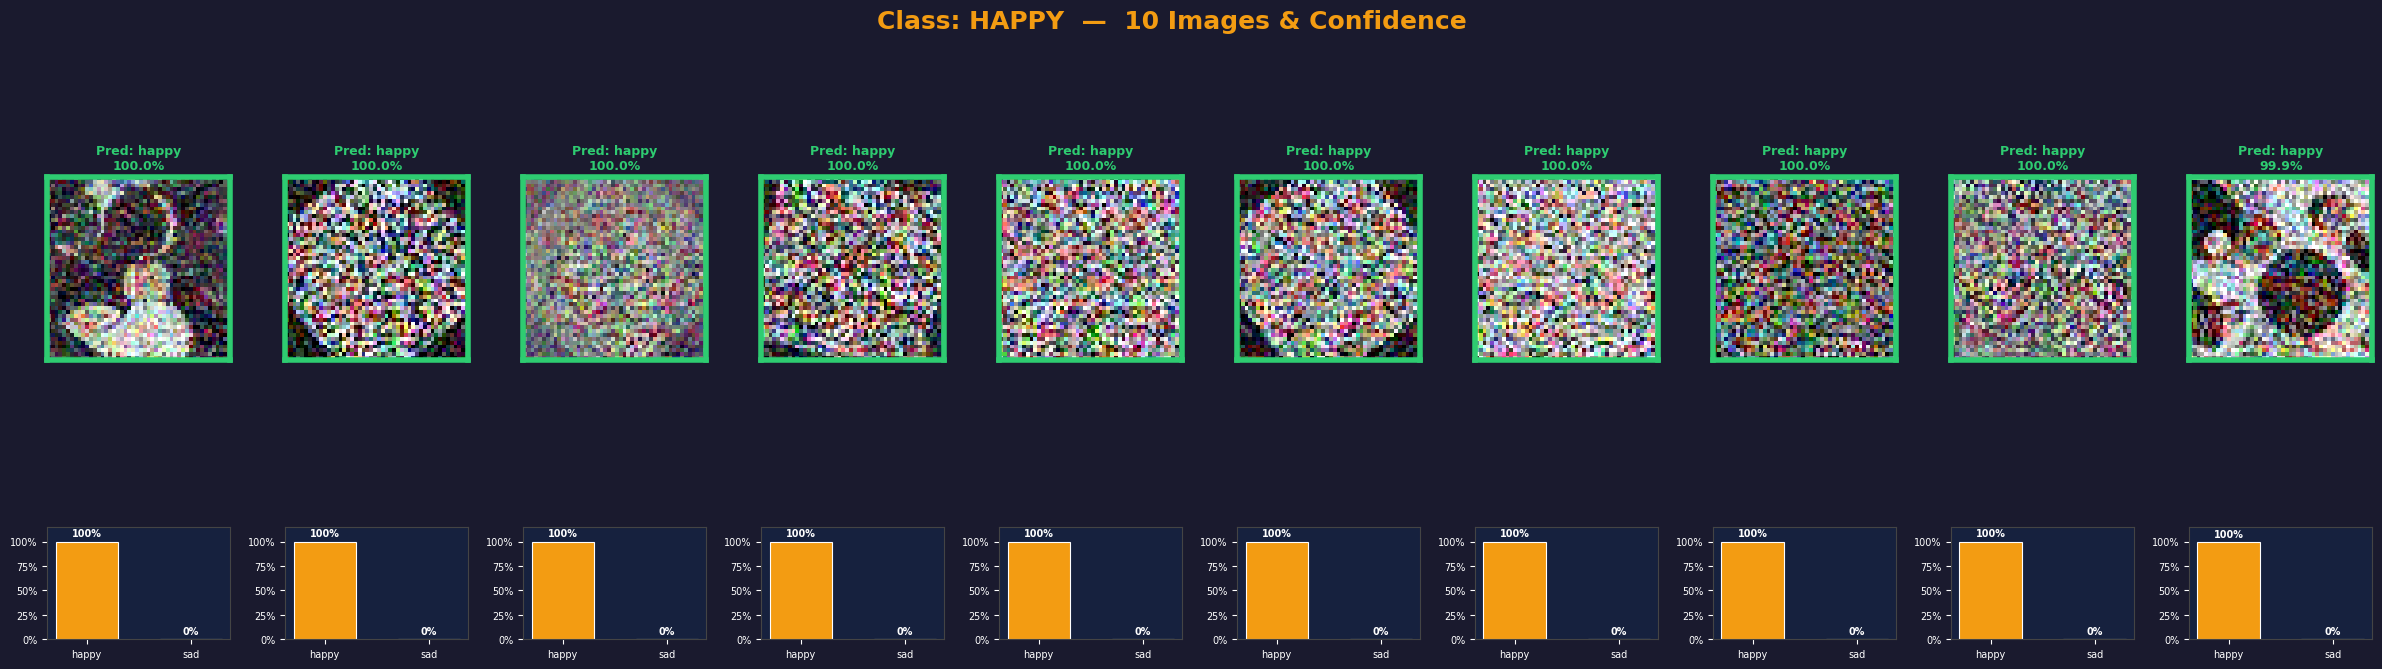

/tmp/ipykernel_5405/396108980.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: confidence_sad.png


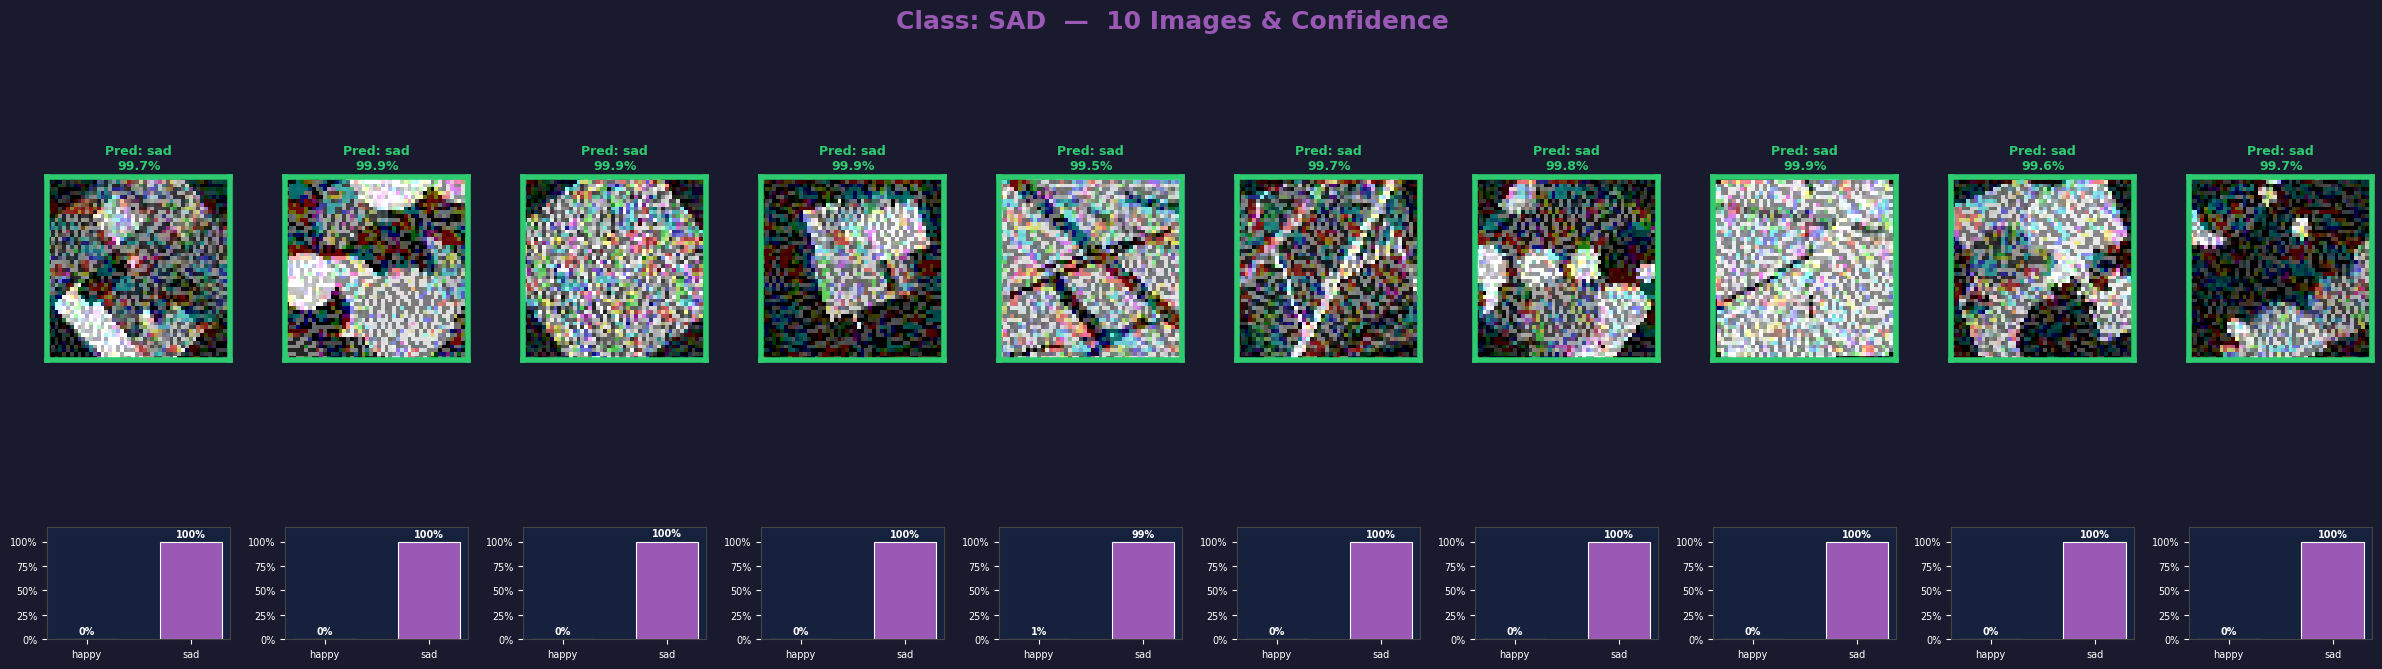


Done!


In [7]:
import os
import random
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
MODEL_PATH    = "/home/student/Downloads/copycat_fer_project/target_mobilenetv2_2class.pth"
DATA_ROOT     = "/home/student/Downloads/copycat_fer_project/npdd_sl"
CLASS_NAMES   = ["happy", "sad"] # Updated to 2 classes
NUM_PER_CLASS = 10   
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load model ──
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.last_channel, 2) # Updated to 2
state = torch.load(MODEL_PATH, map_location=DEVICE)
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]
elif isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
model.load_state_dict(state, strict=False)
model.to(DEVICE)
model.eval()
print("Model loaded.")

transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Collect 10 images per class ──
random.seed(42)
all_images = []

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    chosen = random.sample(files, min(NUM_PER_CLASS, len(files)))
    for f in chosen:
        img = Image.open(os.path.join(cls_dir, f)).convert("RGB")
        all_images.append((img, cls))
    print(f"  {cls}: {len(chosen)} images")

# Updated colors for 2 classes
BAR_COLORS   = ["#f39c12", "#9b59b6"]
CLASS_COLORS = {"happy": "#f39c12", "sad": "#9b59b6"}

# ── One figure per class, 10 columns ──
for ci, cls in enumerate(CLASS_NAMES):
    imgs_for_cls = [x for x in all_images if x[1] == cls]

    fig = plt.figure(figsize=(30, 7))   # wider for 10 images
    fig.patch.set_facecolor("#1a1a2e")
    fig.suptitle(f"Class: {cls.upper()}  —  10 Images & Confidence",
                 fontsize=18, fontweight="bold",
                 color=CLASS_COLORS[cls], y=1.01)

    gs = gridspec.GridSpec(2, 10, figure=fig,   # ← 10 columns
                           hspace=0.4, wspace=0.3,
                           height_ratios=[3, 1])

    for i, (img, true_label) in enumerate(imgs_for_cls):
        tensor = transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

        pred    = CLASS_NAMES[np.argmax(probs)]
        conf    = probs.max()
        correct = (pred == true_label)
        border  = "#2ecc71" if correct else "#e74c3c"

        # Image subplot
        ax_img = fig.add_subplot(gs[0, i])
        ax_img.imshow(img)
        ax_img.set_xticks([]); ax_img.set_yticks([])
        for spine in ax_img.spines.values():
            spine.set_edgecolor(border)
            spine.set_linewidth(4)
        ax_img.set_title(f"Pred: {pred}\n{conf:.1%}",
                         fontsize=9, fontweight="bold",
                         color=border, pad=6)

        # Bar subplot
        ax_bar = fig.add_subplot(gs[1, i])
        bars = ax_bar.bar(CLASS_NAMES, probs, color=BAR_COLORS,
                          edgecolor="white", linewidth=0.8, width=0.6)
        ax_bar.set_ylim(0, 1.15)
        ax_bar.set_facecolor("#16213e")
        ax_bar.tick_params(colors="white", labelsize=7)
        ax_bar.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        for spine in ax_bar.spines.values():
            spine.set_color("#444")
        for bar, p in zip(bars, probs):
            ax_bar.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.03,
                        f"{p:.0%}", ha="center", va="bottom",
                        fontsize=7, color="white", fontweight="bold")

    plt.tight_layout()
    fname = f"confidence_{cls}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved: {fname}")
    plt.show()

print("\nDone!")

Model loaded.
  happy: 10 images
  sad: 10 images


/tmp/ipykernel_5405/1825305022.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: confidence_happy.png


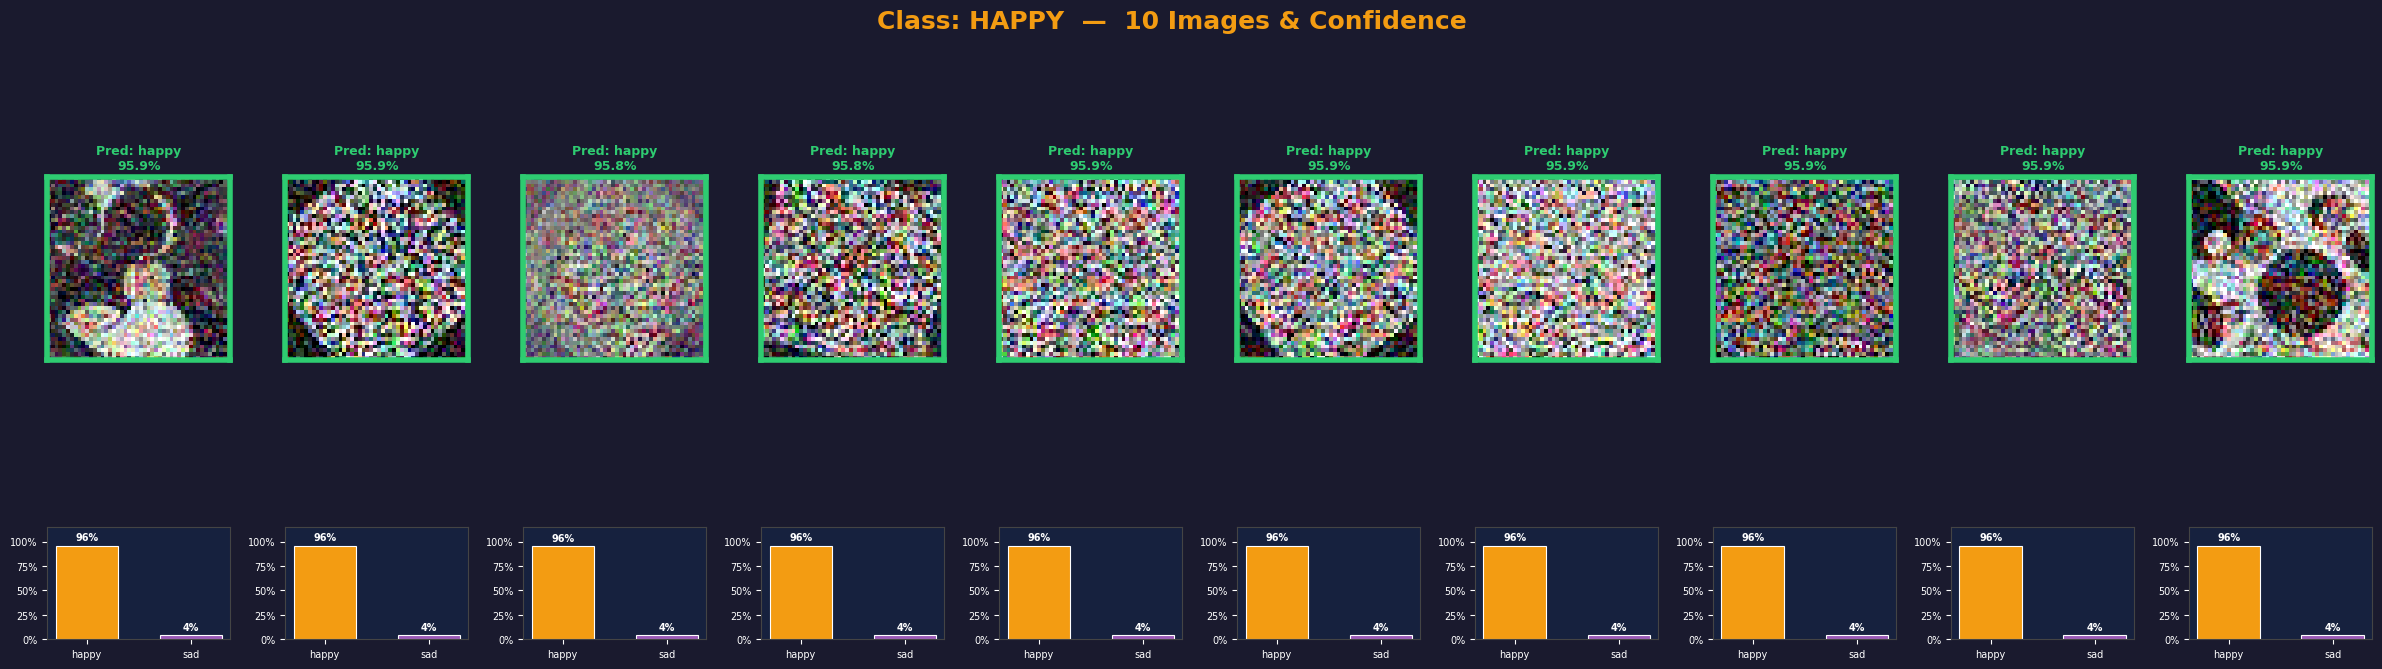

/tmp/ipykernel_5405/1825305022.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: confidence_sad.png


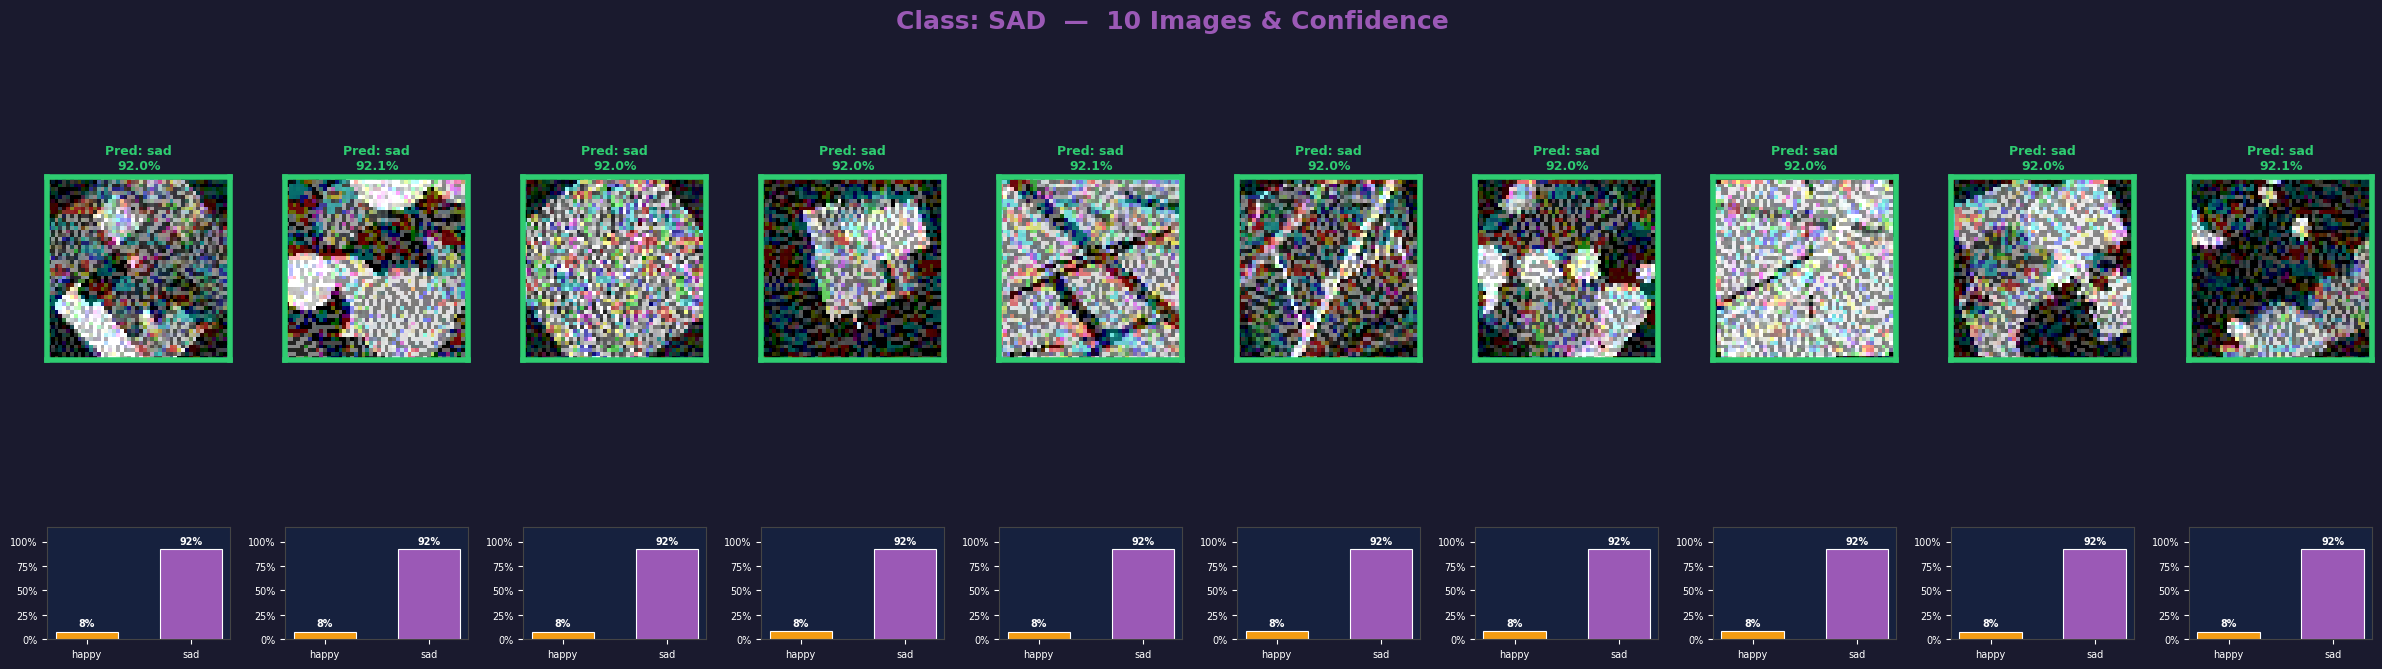


Done!


In [8]:
import os
import random
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
MODEL_PATH    = "/home/student/Downloads/copycat_fer_project/copycat2_mobilenetv2_2class.pth"
DATA_ROOT     = "/home/student/Downloads/copycat_fer_project/npdd_sl"
CLASS_NAMES   = ["happy", "sad"] # Updated to 2 classes
NUM_PER_CLASS = 10   
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load model ──
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.last_channel, 2) # Updated to 2
state = torch.load(MODEL_PATH, map_location=DEVICE)
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]
elif isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
model.load_state_dict(state, strict=False)
model.to(DEVICE)
model.eval()
print("Model loaded.")

transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Collect 10 images per class ──
random.seed(42)
all_images = []

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    chosen = random.sample(files, min(NUM_PER_CLASS, len(files)))
    for f in chosen:
        img = Image.open(os.path.join(cls_dir, f)).convert("RGB")
        all_images.append((img, cls))
    print(f"  {cls}: {len(chosen)} images")

# Updated colors for 2 classes
BAR_COLORS   = ["#f39c12", "#9b59b6"]
CLASS_COLORS = {"happy": "#f39c12", "sad": "#9b59b6"}

# ── One figure per class, 10 columns ──
for ci, cls in enumerate(CLASS_NAMES):
    imgs_for_cls = [x for x in all_images if x[1] == cls]

    fig = plt.figure(figsize=(30, 7))   # wider for 10 images
    fig.patch.set_facecolor("#1a1a2e")
    fig.suptitle(f"Class: {cls.upper()}  —  10 Images & Confidence",
                 fontsize=18, fontweight="bold",
                 color=CLASS_COLORS[cls], y=1.01)

    gs = gridspec.GridSpec(2, 10, figure=fig,   # ← 10 columns
                           hspace=0.4, wspace=0.3,
                           height_ratios=[3, 1])

    for i, (img, true_label) in enumerate(imgs_for_cls):
        tensor = transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

        pred    = CLASS_NAMES[np.argmax(probs)]
        conf    = probs.max()
        correct = (pred == true_label)
        border  = "#2ecc71" if correct else "#e74c3c"

        # Image subplot
        ax_img = fig.add_subplot(gs[0, i])
        ax_img.imshow(img)
        ax_img.set_xticks([]); ax_img.set_yticks([])
        for spine in ax_img.spines.values():
            spine.set_edgecolor(border)
            spine.set_linewidth(4)
        ax_img.set_title(f"Pred: {pred}\n{conf:.1%}",
                         fontsize=9, fontweight="bold",
                         color=border, pad=6)

        # Bar subplot
        ax_bar = fig.add_subplot(gs[1, i])
        bars = ax_bar.bar(CLASS_NAMES, probs, color=BAR_COLORS,
                          edgecolor="white", linewidth=0.8, width=0.6)
        ax_bar.set_ylim(0, 1.15)
        ax_bar.set_facecolor("#16213e")
        ax_bar.tick_params(colors="white", labelsize=7)
        ax_bar.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        for spine in ax_bar.spines.values():
            spine.set_color("#444")
        for bar, p in zip(bars, probs):
            ax_bar.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.03,
                        f"{p:.0%}", ha="center", va="bottom",
                        fontsize=7, color="white", fontweight="bold")

    plt.tight_layout()
    fname = f"confidence_{cls}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved: {fname}")
    plt.show()

print("\nDone!")

Using device: cuda
Classes found: ['happy', 'sad']
Evaluating model on FER Test Data...


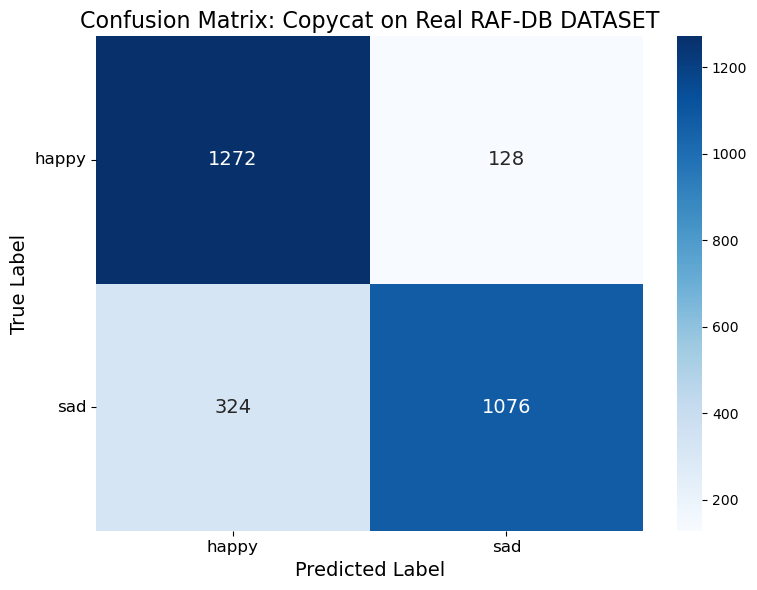


CLASSIFICATION RATIOS (METRICS REPORT)
              precision    recall  f1-score   support

       happy       0.80      0.91      0.85      1400
         sad       0.89      0.77      0.83      1400

    accuracy                           0.84      2800
   macro avg       0.85      0.84      0.84      2800
weighted avg       0.85      0.84      0.84      2800


Overall Accuracy Ratio: 2348/2800 (83.86%)


In [37]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PATHS & CONFIG
# ==========================================
MODEL_PATH   = "/home/student/Downloads/copycat_fer_project/copycat2_mobilenetv2_2class.pth"
FER_TEST_DIR = "/home/student/Downloads/copycat_fer_project/TEST"

IMG_SIZE    = 48
NUM_CLASSES = 2
BATCH_SIZE  = 32
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ==========================================
# TRANSFORMS & DATA
# ==========================================
test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

fer_test_ds = datasets.ImageFolder(FER_TEST_DIR, transform=test_tf)
fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False)

class_names = fer_test_ds.classes
print(f"Classes found: {class_names}")

# ==========================================
# MODEL SETUP
# ==========================================
model = models.mobilenet_v2(weights=None) 
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ==========================================
# PREDICTIONS
# ==========================================
all_preds = []
all_labels = []

print("Evaluating model on FER Test Data...")
with torch.no_grad():
    for x, y in fer_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        preds = out.argmax(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# ==========================================
# CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14}) # Increase font size for numbers

plt.title('Confusion Matrix: Copycat on Real RAF-DB DATASET', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# RATIOS / METRICS REPORT
# ==========================================
print("\n" + "="*50)
print("CLASSIFICATION RATIOS (METRICS REPORT)")
print("="*50)

# This generates the ratios for Accuracy, Precision, Recall, and F1-Score
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

# Calculate and print raw accuracy percentage
total_predictions = len(all_labels)
correct_predictions = np.sum(np.array(all_labels) == np.array(all_preds))
accuracy_percentage = (correct_predictions / total_predictions) * 100

print(f"\nOverall Accuracy Ratio: {correct_predictions}/{total_predictions} ({accuracy_percentage:.2f}%)")
print("="*50)

Using device: cuda
Classes found: ['happy', 'sad']
Evaluating model on FER Test Data...


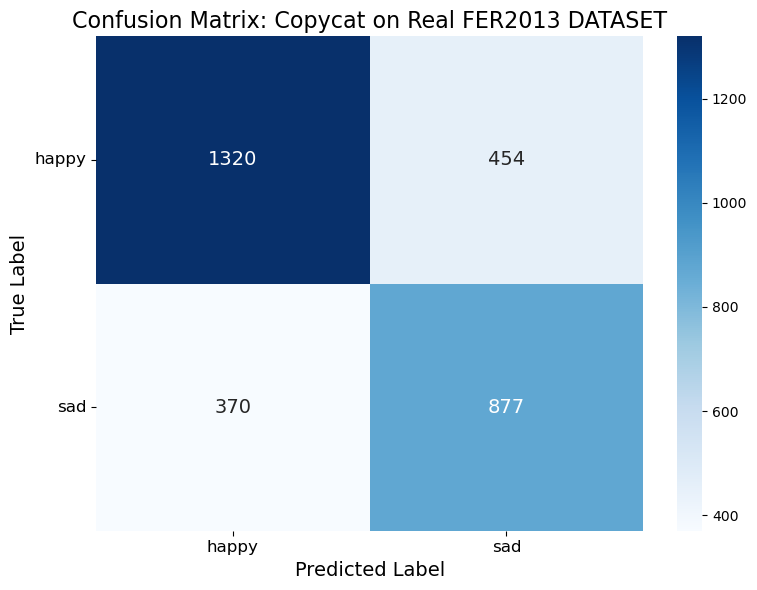


CLASSIFICATION RATIOS (METRICS REPORT)
              precision    recall  f1-score   support

       happy       0.78      0.74      0.76      1774
         sad       0.66      0.70      0.68      1247

    accuracy                           0.73      3021
   macro avg       0.72      0.72      0.72      3021
weighted avg       0.73      0.73      0.73      3021


Overall Accuracy Ratio: 2197/3021 (72.72%)


In [38]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PATHS & CONFIG
# ==========================================
MODEL_PATH   = "/home/student/Downloads/copycat_fer_project/copycat2_mobilenetv2_2class.pth"
FER_TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"

IMG_SIZE    = 48
NUM_CLASSES = 2
BATCH_SIZE  = 32
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ==========================================
# TRANSFORMS & DATA
# ==========================================
test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

fer_test_ds = datasets.ImageFolder(FER_TEST_DIR, transform=test_tf)
fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False)

class_names = fer_test_ds.classes
print(f"Classes found: {class_names}")

# ==========================================
# MODEL SETUP
# ==========================================
model = models.mobilenet_v2(weights=None) 
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ==========================================
# PREDICTIONS
# ==========================================
all_preds = []
all_labels = []

print("Evaluating model on FER Test Data...")
with torch.no_grad():
    for x, y in fer_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        preds = out.argmax(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# ==========================================
# CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14}) # Increase font size for numbers

plt.title('Confusion Matrix: Copycat on Real FER2013 DATASET', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# RATIOS / METRICS REPORT
# ==========================================
print("\n" + "="*50)
print("CLASSIFICATION RATIOS (METRICS REPORT)")
print("="*50)

# This generates the ratios for Accuracy, Precision, Recall, and F1-Score
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

# Calculate and print raw accuracy percentage
total_predictions = len(all_labels)
correct_predictions = np.sum(np.array(all_labels) == np.array(all_preds))
accuracy_percentage = (correct_predictions / total_predictions) * 100

print(f"\nOverall Accuracy Ratio: {correct_predictions}/{total_predictions} ({accuracy_percentage:.2f}%)")
print("="*50)